Q2: Battery-Aware Robot Navigation

Defining Environment

In [1]:
GRID_SIZE = 10
B = 6
GAMMA = 0.9
GOAL = (9, 9)
CHARGING_STATIONS = {(1, 3), (5, 8), (2,7)}   
#CHARGING_STATIONS = {(1, 3), (7, 5), (3,4)} 
# CHARGING_STATIONS = {(8,0)}


FAILURE_STATE = "FAILURE"
states_battery = []

for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        for b in range(B+1):
            states_battery.append((x, y, b))

states_battery.append(FAILURE_STATE)

terminal_states_battery = {FAILURE_STATE}

# Goal states are terminal
for b in range(B+1):
    terminal_states_battery.add((GOAL[0], GOAL[1], b))


def get_available_actions(state):               #I added this function as i didn't want to allow recharge action at non charging stations
    
    if state in terminal_states_battery:
        return []
    
    x, y, b = state

    actions = ["Up", "Down", "Left", "Right"]

    if (x, y) in CHARGING_STATIONS:
        actions.append("Recharge")

    return actions




def get_transitions_battery(state, action):

    if state in terminal_states_battery:
        return []

    x, y, b = state

    if action == "Recharge":

        if (x, y) in CHARGING_STATIONS:
            return [(1.0, (x, y, B), -2)]
        else:
            return [(1.0, (x, y, b), -2)]  # self-loop


    if b == 0:
        return [(1.0, FAILURE_STATE, -100)]

    if action == "Up":
        nx, ny = x, y+1
    elif action == "Down":
        nx, ny = x, y-1
    elif action == "Left":
        nx, ny = x-1, y
    elif action == "Right":
        nx, ny = x+1, y

    # valid or not
    if nx < 0 or nx >= GRID_SIZE or ny < 0 or ny >= GRID_SIZE:
        nx, ny = x, y   # stay in place

    new_b = b - 1

    
    if new_b == 0 and (nx, ny) not in CHARGING_STATIONS and (nx, ny) != GOAL:       # Battery depletion
        return [(1.0, FAILURE_STATE, -100)]


    if (nx, ny) == GOAL:                                                            # Goal reached
        return [(1.0, (nx, ny, new_b), 100)]

    return [(1.0, (nx, ny, new_b), -1)]



Value Iteration

In [2]:
def run_value_iteration_battery(states, terminal_states, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in get_available_actions(s):
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extracting the optimal policy
    policy = {}

    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in get_available_actions(s):
            val = 0
            transitions = get_transitions_battery(s, a)

            for p, s_next, r in transitions:
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

    return V, policy, iterations


V_battery, policy_battery, iters_battery = run_value_iteration_battery(
    states_battery,
    terminal_states_battery
)

print("Value Iteration converged in:", iters_battery, "iterations")


Value Iteration converged in: 24 iterations


Simulating for a starting path

Path length: 22
Battery levels along path: [6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1]


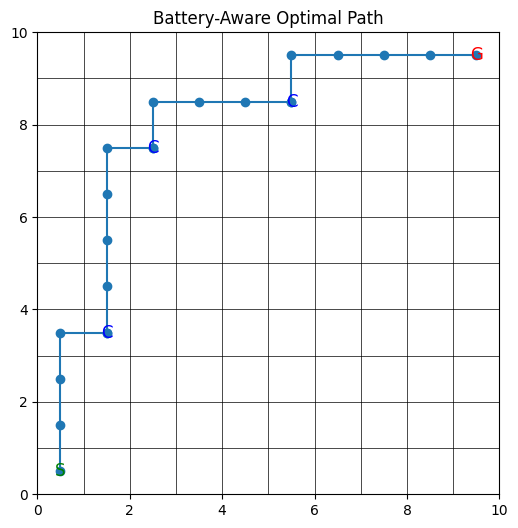

In [3]:
start_state = (0, 0, B)

def simulate_path(policy, start_state, max_steps=100):

    state = start_state
    path = []
    battery_levels = []

    for _ in range(max_steps):
        
        if state == FAILURE_STATE:
            print("Reached FAILURE state")
            break

        x, y, b = state
        path.append((x, y))
        battery_levels.append(b)

        if state in terminal_states_battery:
            break

        action = policy[state]
        transitions = get_transitions_battery(state, action)

        if not transitions:
            break

        _, next_state, _ = transitions[0]

        state = next_state

    return path, battery_levels

start_state = (0, 0, B)

path, battery_levels = simulate_path(policy_battery, start_state)


import matplotlib.pyplot as plt

def plot_path(path):

    plt.figure(figsize=(6,6))

    for i in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [i, i], color='black', linewidth=0.5)
        plt.plot([i, i], [0, GRID_SIZE], color='black', linewidth=0.5)

    xs = [p[0] + 0.5 for p in path]
    ys = [p[1] + 0.5 for p in path]

    plt.plot(xs, ys, marker='o')

    plt.text(path[0][0] + 0.5, path[0][1] + 0.5, "S",
             ha='center', va='center', fontsize=12, color='green')


    gx, gy = GOAL
    plt.text(gx + 0.5, gy + 0.5, "G",
             ha='center', va='center', fontsize=12, color='red')

    for (cx, cy) in CHARGING_STATIONS:
        plt.text(cx + 0.5, cy + 0.5, "C",
                 ha='center', va='center', fontsize=12, color='blue')

    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.title("Battery-Aware Optimal Path")
    plt.show()



print("Path length:", len(path))
print("Battery levels along path:", battery_levels)

plot_path(path)


Policy Iteration

In [4]:
import random
def run_policy_iteration_battery(states, terminal_states, tol=1e-4, max_iters=1000):

    policy = {}

    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            if actions:
                policy[s] = random.choice(actions)

    V = {s: 0.0 for s in states}

    iterations = 0

    for k in range(max_iters):

        # Policy Evaluation
        while True:

            delta = 0
            V_new = V.copy()

            for s in states:

                if s in terminal_states:
                    continue

                a = policy[s]
                val = 0

                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break

        # Policy Improvement
        policy_stable = True

        for s in states:

            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_val = -float("inf")

            for a in get_available_actions(s):

                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    return V, policy, iterations

V_pi_battery, policy_pi_battery, pi_iters = run_policy_iteration_battery(
    states_battery,
    terminal_states_battery
)

print("Battery-aware Policy Iteration converged in:", pi_iters, "iterations")


Battery-aware Policy Iteration converged in: 13 iterations


PI Path length: 22
PI Battery levels: [6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1]


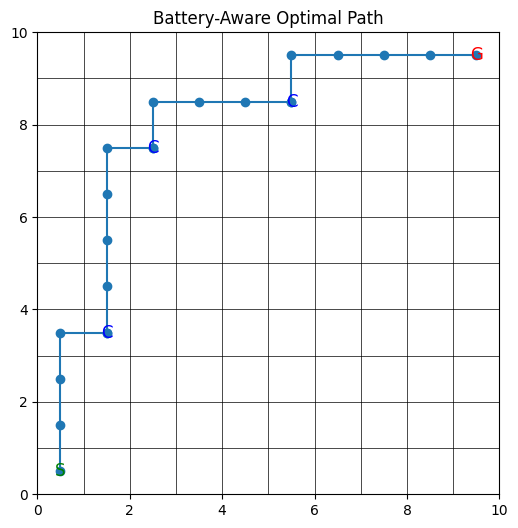

In [5]:
start_state = (0, 0, B)

path_pi, battery_levels_pi = simulate_path(policy_pi_battery, start_state)

print("PI Path length:", len(path_pi))
print("PI Battery levels:", battery_levels_pi)

plot_path(path_pi)


Monte Carlo

In [6]:
def run_monte_carlo_battery(states, terminal_states,
                            num_episodes=5000,
                            epsilon=0.1):

    # Initialize Q(s,a)
    Q = {}
    returns_count = {}

    for s in states:
        if s not in terminal_states:
            Q[s] = {}
            returns_count[s] = {}
            for a in get_available_actions(s):
                Q[s][a] = 0.0
                returns_count[s][a] = 0


    policy = {}
    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            if actions:
                policy[s] = random.choice(actions)      #random policy


    for episode in range(num_episodes):

        start_positions = [(x, y, B)
                           for x in range(GRID_SIZE)
                           for y in range(GRID_SIZE)
                           if (x, y, B) not in terminal_states]

        state = random.choice(start_positions)

        episode_data = []


        while state not in terminal_states:

            actions = get_available_actions(state)

            if random.random() < epsilon:
                action = random.choice(actions)
            else:
                action = policy[state]

            transitions = get_transitions_battery(state, action)

            if not transitions:
                break

            _, next_state, reward = transitions[0]

            episode_data.append((state, action, reward))
            state = next_state



        G = 0                                               # First-Visit Return Update
        visited = []

        for t in reversed(range(len(episode_data))):

            s, a, r = episode_data[t]
            G = GAMMA * G + r

            if (s, a) not in visited:

                visited.append((s, a))

                returns_count[s][a] += 1

                Q[s][a] += (G - Q[s][a]) / returns_count[s][a]

                # Policy Improvement
                best_action = max(Q[s], key=Q[s].get)
                policy[s] = best_action

    return Q, policy


Q_mc_battery, policy_mc_battery = run_monte_carlo_battery(
    states_battery,
    terminal_states_battery,
    num_episodes=8000,
    epsilon=0.1
)

print("Monte Carlo training completed.")


Monte Carlo training completed.


MC Path length: 24
MC Battery levels: [6, 5, 4, 3, 2, 1, 0, 6, 5, 4, 3, 2, 1, 6, 5, 4, 3, 2, 6, 5, 4, 3, 2, 1]


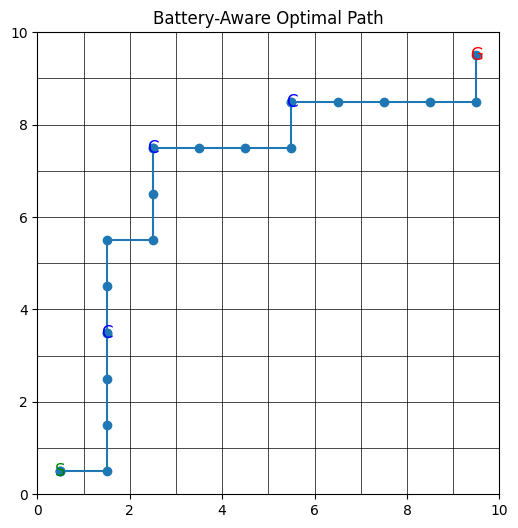

In [7]:
start_state = (0, 0, B)

path_mc, battery_levels_mc = simulate_path(policy_mc_battery, start_state)

print("MC Path length:", len(path_mc))
print("MC Battery levels:", battery_levels_mc)

plot_path(path_mc)


Plotting value iteration vs policy iteration till convergence 

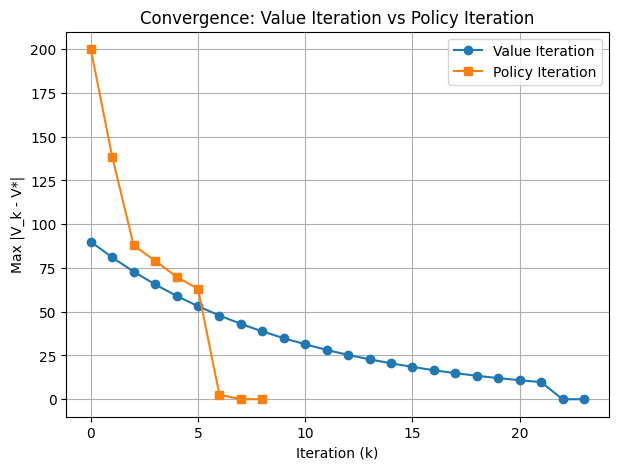

In [8]:
V_star, _, _ = run_value_iteration_battery(
    states_battery,
    terminal_states_battery
)
def value_iteration_convergence(states, terminal_states, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    errors = []

    for k in range(max_iters):

        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in get_available_actions(s):
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new

        # Compute error w.r.t V*
        max_error = 0
        for s in states:
            max_error = max(max_error, abs(V[s] - V_star[s]))

        errors.append(max_error)

        if delta < tol:
            break

    return errors
def policy_iteration_convergence(states, terminal_states, tol=1e-4, max_iters=1000):

    import random

    policy = {}
    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            if actions:
                policy[s] = random.choice(actions)

    V = {s: 0.0 for s in states}
    errors = []

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = policy[s]
                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break

        # Compute error w.r.t V*
        max_error = 0
        for s in states:
            max_error = max(max_error, abs(V[s] - V_star[s]))

        errors.append(max_error)

        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_val = -float("inf")

            for a in get_available_actions(s):

                val = 0
                transitions = get_transitions_battery(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        if policy_stable:
            break

    return errors


vi_errors = value_iteration_convergence(
    states_battery,
    terminal_states_battery
)

pi_errors = policy_iteration_convergence(
    states_battery,
    terminal_states_battery
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(vi_errors, marker='o', label="Value Iteration")
plt.plot(pi_errors, marker='s', label="Policy Iteration")

plt.xlabel("Iteration (k)")
plt.ylabel("Max |V_k - V*|")
plt.title("Convergence: Value Iteration vs Policy Iteration")
plt.legend()
plt.grid(True)

plt.show()


Monte Carlo Implementation 

In [9]:
import random
from collections import defaultdict
import numpy as np
import time
import tracemalloc

def run_monte_carlo_battery(
    states,
    terminal_states,
    GAMMA,
    get_available_actions,
    get_transitions,
    V_opt,
    episodes=5000,
    epsilon=0.1,
    max_steps=200
):

    start_time = time.time()
    tracemalloc.start()

    Q = defaultdict(lambda: {})
    returns = defaultdict(list)

    policy = {}

    # Initialize Q and policy
    for s in states:
        if s not in terminal_states:
            actions = get_available_actions(s)
            Q[s] = {a: 0.0 for a in actions}
            policy[s] = random.choice(actions)

    episode_rewards = []
    value_error = []

    for ep in range(episodes):

        state = random.choice(
            [s for s in states if s not in terminal_states]
        )

        episode = []
        total_reward = 0
        steps = 0

        # Generate episode
        while state not in terminal_states and steps < max_steps:

            actions = get_available_actions(state)

            if random.random() < epsilon:
                action = random.choice(actions)
            else:
                action = policy[state]

            transitions = get_transitions(state, action)

            p, next_state, reward = transitions[0]

            episode.append((state, action, reward))
            total_reward += reward

            state = next_state
            steps += 1

        episode_rewards.append(total_reward)

        # Backward update
        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = GAMMA * G + r

            if (s, a) not in visited:
                returns[(s, a)].append(G)
                Q[s][a] = np.mean(returns[(s, a)])
                visited.add((s, a))

                # Policy improvement
                best_action = max(Q[s], key=Q[s].get)
                policy[s] = best_action

        # ---- Value error wrt VI ----
        diff = 0
        count = 0

        for s in states:
            if s in terminal_states:
                continue
            if s in Q:
                mc_v = max(Q[s].values())
                diff += abs(mc_v - V_opt[s])
                count += 1

        value_error.append(diff / max(count, 1))

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return Q, policy, runtime, peak, episode_rewards, value_error

In [11]:
Q_mc_b, mc_policy_b, mc_time_b, mc_mem_b, rewards_b, error_b = run_monte_carlo_battery(
    states_battery,
    terminal_states_battery,
    GAMMA,
    get_available_actions,
    get_transitions_battery,
    V_battery,
    episodes=5000,
    epsilon=0.1
)

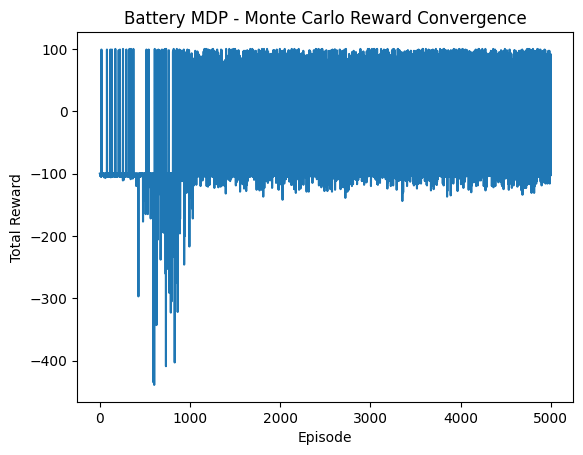

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rewards_b)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Battery MDP - Monte Carlo Reward Convergence")
plt.show()

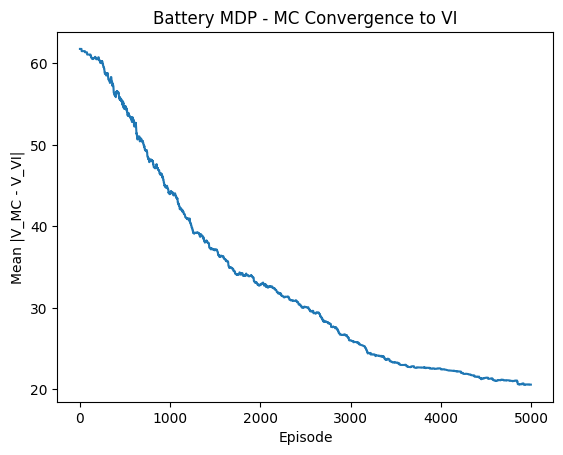

In [13]:
plt.figure()
plt.plot(error_b)
plt.xlabel("Episode")
plt.ylabel("Mean |V_MC - V_VI|")
plt.title("Battery MDP - MC Convergence to VI")
plt.show()